# Multi Output prediction of NOx and CO through ML

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
# loading data
df = pd.read_csv('/kaggle/input/notebooks/haidery05/notebookc1da314d82/feature_engineered_data.csv')
df.head()

,AT,AP,AH,AFDP,GTEP,TIT,TAT,CO,NOX,Gas_Efficiency,CO_log,cluster
0,-1.762362,0.871052,0.401627,-0.451875,-0.377702,0.272119,0.536589,-0.368849,1.426499,-0.235812,-0.500266,0.632059
1,-1.801920,0.809164,0.440351,-0.458207,-0.384376,0.266417,0.568742,-0.368849,1.462891,-0.242267,-0.500266,0.632059
2,-1.854113,0.824636,0.483432,-0.442831,-0.375081,0.289227,0.589203,-0.368849,1.582687,-0.225065,-0.500266,0.632059
3,-1.875718,0.809164,0.523263,-0.445415,-0.393909,0.289227,0.586280,-0.368849,1.473852,-0.232739,-0.500266,0.632059
4,-1.874644,0.731804,0.505837,-0.448904,-0.392479,0.255012,0.561434,-0.368849,1.433006,-0.253619,-0.500266,0.632059


In [2]:
#X = df.drop(['CO','NOX'], axis=1)
#y = df[['CO','NOX']]
X = df.drop(['CO','NOX','CO_log'], axis=1)
y = df[['CO','NOX']]

To predict the emissions of both CO and NOx we have used a multi-output setup.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

we have splited the data into training nad testing sets so that model performance can be evaluated.

# MODEL 1 (Random Forest)

In [4]:
rf = MultiOutputRegressor(RandomForestRegressor())
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# Model 2 (XGBoost)

In [5]:
xgb = MultiOutputRegressor(XGBRegressor())
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

# Model 3 (LightGBM)

In [6]:
lgb = MultiOutputRegressor(LGBMRegressor())
lgb.fit(X_train, y_train)

lgb_pred = lgb.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003321 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2014
[LightGBM] [Info] Number of data points in the train set: 29386, number of used features: 9
[LightGBM] [Info] Start training from score 0.000570
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000440 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2014
[LightGBM] [Info] Number of data points in the train set: 29386, number of used features: 9
[LightGBM] [Info] Start training from score 0.001538


# Evaluation

The above models are evaluated using R² and RMSE for both NOx and CO output.

In [7]:
def evaluate(y_test, pred, model_name):
    print(f"--- {model_name} ---")
    
    print("CO R2:", r2_score(y_test['CO'], pred[:,0]))
    print("NOX R2:", r2_score(y_test['NOX'], pred[:,1]))
    
    print("CO RMSE:", np.sqrt(mean_squared_error(y_test['CO'], pred[:,0])))
    print("NOX RMSE:", np.sqrt(mean_squared_error(y_test['NOX'], pred[:,1])))
    
    print("\n")

evaluate(y_test, rf_pred, "Random Forest")
evaluate(y_test, xgb_pred, "XGBoost")
evaluate(y_test, lgb_pred, "LightGBM")

--- Random Forest ---
CO R2: 0.7620347611820324
NOX R2: 0.8762559977294284
CO RMSE: 0.5083185253420907
NOX RMSE: 0.34675289424750266


--- XGBoost ---
CO R2: 0.7294232799842458
NOX R2: 0.858527351680949
CO RMSE: 0.542031331081119
NOX RMSE: 0.3707611813174343


--- LightGBM ---
CO R2: 0.7579182282041397
NOX R2: 0.8337419071077782
CO RMSE: 0.5126963451839913
NOX RMSE: 0.4019290649733154




# Best model selection

From the above results we can see that Random Forest have better R2 values for both CO and NOx and lower RMSE values as well.

# Feature Importance

**CO**

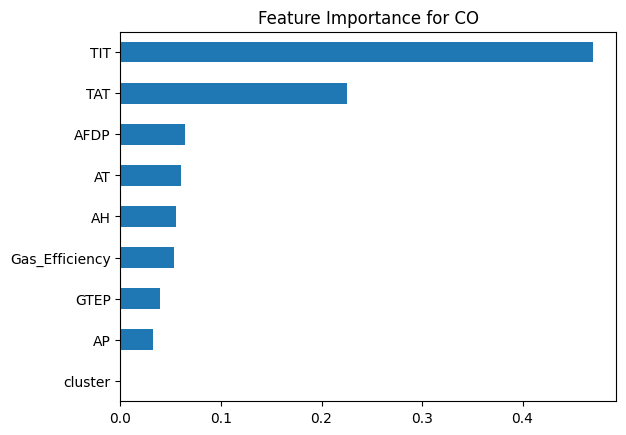

In [8]:


co_model = rf.estimators_[0]  # CO model

co_importance = pd.Series(co_model.feature_importances_, index=X.columns)
co_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance for CO")
plt.show()

At first CO emission was dominently dependet on CO_log which is now removed to avoid data lickage as it was directly derived from target variable CO. After removing that feature it depends on other features as well.

**NOx**

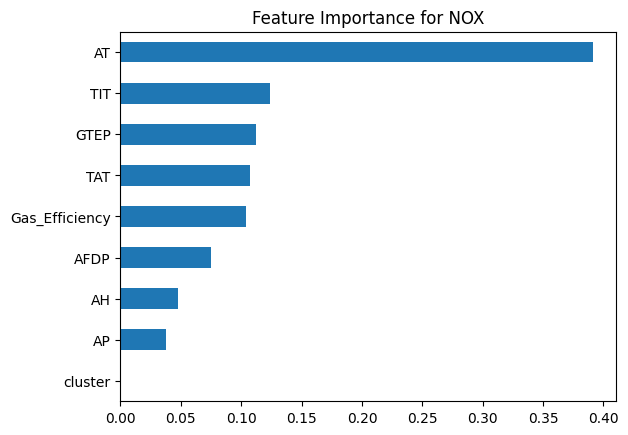

In [9]:
nox_model = rf.estimators_[1]  # NOX model

nox_importance = pd.Series(nox_model.feature_importances_, index=X.columns)
nox_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance for NOX")
plt.show()

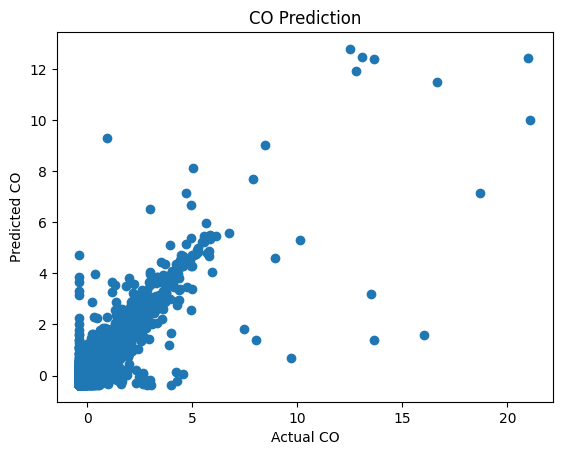

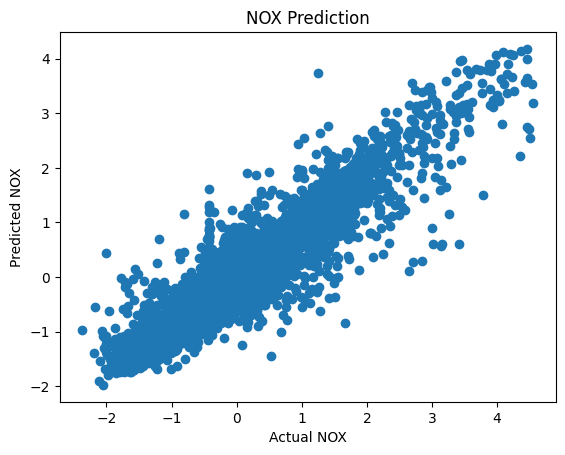

In [10]:
plt.scatter(y_test['CO'], rf_pred[:,0])
plt.xlabel("Actual CO")
plt.ylabel("Predicted CO")
plt.title("CO Prediction")
plt.show()

plt.scatter(y_test['NOX'], rf_pred[:,1])
plt.xlabel("Actual NOX")
plt.ylabel("Predicted NOX")
plt.title("NOX Prediction")
plt.show()